# Virtual screening with a 2D CNN on structure images

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yboulaamane/cadd-labs/blob/main/cnn_images_vs.ipynb)

Same question as the fingerprint notebook, different senses: this time the model *looks* at a
picture of each molecule, the way a chemist glances at a structure. Each MAO-B compound is drawn
by RDKit as a 200x200 image and classified by a 2D convolutional network, with a fingerprint
random forest as the baseline to beat.

**What you'll do**

- Render every compound to an image, carefully keeping images and labels aligned.
- Train an image CNN, handling imbalance with class weights instead of copying images.
- Compare it with the fingerprint random forest on the same held-out compounds.

Runtime: a **GPU** (Runtime -> Change runtime type) trains fastest, but a CPU works too: training
took about 4 minutes on a 4-core CPU in the run saved here.

## Setup

RDKit is added; TensorFlow, scikit-learn, NumPy and Matplotlib are on Colab.

In [ ]:
%pip install -q rdkit seaborn

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.titlepad": 14,
    "savefig.bbox": "tight",
})

## Data: MAO-B inhibitors from ChEMBL

The compounds and their activities come from [ChEMBL](https://www.ebi.ac.uk/chembl/)
target [CHEMBL2039](https://www.ebi.ac.uk/chembl/explore/target/CHEMBL2039),
human monoamine oxidase B. The cell below downloads every activity record for
that target through the ChEMBL web services and turns them into one labelled row
per compound:

* Only IC50 and Ki values in nM that ChEMBL has not flagged as doubtful are used.
* Salts and counter-ions are stripped, so the different salt forms of one compound count once.
* A compound is **active (1)** if its median value is at most 316 nM (pIC50 &ge; 6.5) and
  **inactive (0)** if it is at least 10 &micro;M (pIC50 &le; 5). A compound reported only as
  "> 10 &micro;M" is also inactive. Compounds in between are left out.

The labelled table is saved to `maob_chembl_labelled.csv` and later runs read that file
instead of downloading again. Delete it to refresh the data. ChEMBL data is licensed under
[CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/).

In [3]:
TARGET = "CHEMBL2039"   # monoamine oxidase B, Homo sapiens
ACTIVE_NM = 316         # median IC50 or Ki at or below this: active   (pIC50 >= 6.5)
INACTIVE_NM = 10_000    # median IC50 or Ki at or above this: inactive (pIC50 <= 5)
DATA_FILE = "maob_chembl_labelled.csv"

In [4]:
import os
import time
from urllib.parse import urljoin

import numpy as np
import pandas as pd
import requests
from rdkit import Chem, RDLogger
from rdkit.Chem.MolStandardize import rdMolStandardize

RDLogger.DisableLog("rdApp.*")
CHEMBL_URL = "https://www.ebi.ac.uk"


def fetch_activities(target):
    """Every activity record ChEMBL holds for one target, 1000 per request."""
    url = f"{CHEMBL_URL}/chembl/api/data/activity.json"
    params = {"target_chembl_id": target, "limit": 1000}
    records = []
    while url:
        for attempt in range(5):
            try:
                response = requests.get(url, params=params, timeout=120)
                response.raise_for_status()
                break
            except requests.RequestException:
                if attempt == 4:
                    raise
                time.sleep(2 ** attempt)
        page = response.json()
        records += page["activities"]
        print(f"\rDownloaded {len(records)} of {page['page_meta']['total_count']} records", end="")
        next_page = page["page_meta"]["next"]
        url, params = (urljoin(CHEMBL_URL, next_page), None) if next_page else (None, None)
    print()
    if not records:
        raise ValueError(f"ChEMBL returned no activity records for {target}")
    return pd.DataFrame(records)


def parent_smiles(smiles):
    """Canonical SMILES of the largest fragment, neutralised, or None if RDKit cannot read it."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        return Chem.MolToSmiles(rdMolStandardize.ChargeParent(mol))
    except Exception:
        return None


def label_molecules(activities):
    """One row per parent structure: its first ChEMBL ID, SMILES and label (1 active, 0 inactive)."""
    a = activities.copy()
    a["relation"] = a["standard_relation"].fillna("").str.strip("'")
    a["value"] = pd.to_numeric(a["standard_value"], errors="coerce")
    usable = (a["standard_type"].isin(["IC50", "Ki"]) & (a["standard_units"] == "nM")
              & a["data_validity_comment"].isna() & a["canonical_smiles"].notna()
              & (a["value"] > 0))
    a = a[usable].copy()
    a["smiles"] = a["canonical_smiles"].map(parent_smiles)
    a = a[a["smiles"].notna()]

    median = a[a["relation"] == "="].groupby("smiles")["value"].median()
    labels = pd.Series(np.nan, index=median.index)
    labels[median <= ACTIVE_NM] = 1
    labels[median >= INACTIVE_NM] = 0

    # Compounds with no exact value, only "> x" with x of at least INACTIVE_NM
    above = a[a["relation"].isin([">", ">="]) & (a["value"] >= INACTIVE_NM)]["smiles"]
    only_above = pd.Index(above.unique()).difference(median.index)
    labels = pd.concat([labels, pd.Series(0.0, index=only_above)]).dropna().astype(int)

    first_id = a.sort_values("molecule_chembl_id").groupby("smiles")["molecule_chembl_id"].first()
    data = pd.DataFrame({"molecule_chembl_id": first_id[labels.index].to_numpy(),
                         "smiles": labels.index.to_numpy(),
                         "label": labels.to_numpy()})
    return data.sort_values("molecule_chembl_id", ignore_index=True)

In [5]:
if os.path.exists(DATA_FILE):
    data = pd.read_csv(DATA_FILE)
else:
    data = label_molecules(fetch_activities(TARGET))
    data.to_csv(DATA_FILE, index=False)

n_active = int(data["label"].sum())
print(f"{len(data)} compounds: {n_active} active, {len(data) - n_active} inactive")
data.head()

Downloaded 17947 of 17947 records
3894 compounds: 1538 active, 2356 inactive


,molecule_chembl_id,smiles,label
0,CHEMBL103879,COc1ccc2c(c1)SCC(=O)N2,0
1,CHEMBL104,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,0
2,CHEMBL106771,O=C(/C=C/c1ccc([N+](=O)[O-])cc1)c1ccccc1,1
3,CHEMBL106824,O=C(/C=C/c1cccc([N+](=O)[O-])c1)c1ccccc1,1
4,CHEMBL1076153,NC(=S)N1N=C(c2ccc(Cl)cc2)CC1c1ccc[nH]1,0


## Draw the compounds

Each image is rendered in the same order as the table, so image *i* always matches label *i*.
(The original version of this notebook read the images back with `os.listdir`, whose order is
arbitrary, which silently scrambled the labels. Order matters.)

3894 images of 200x200 (467 MB)


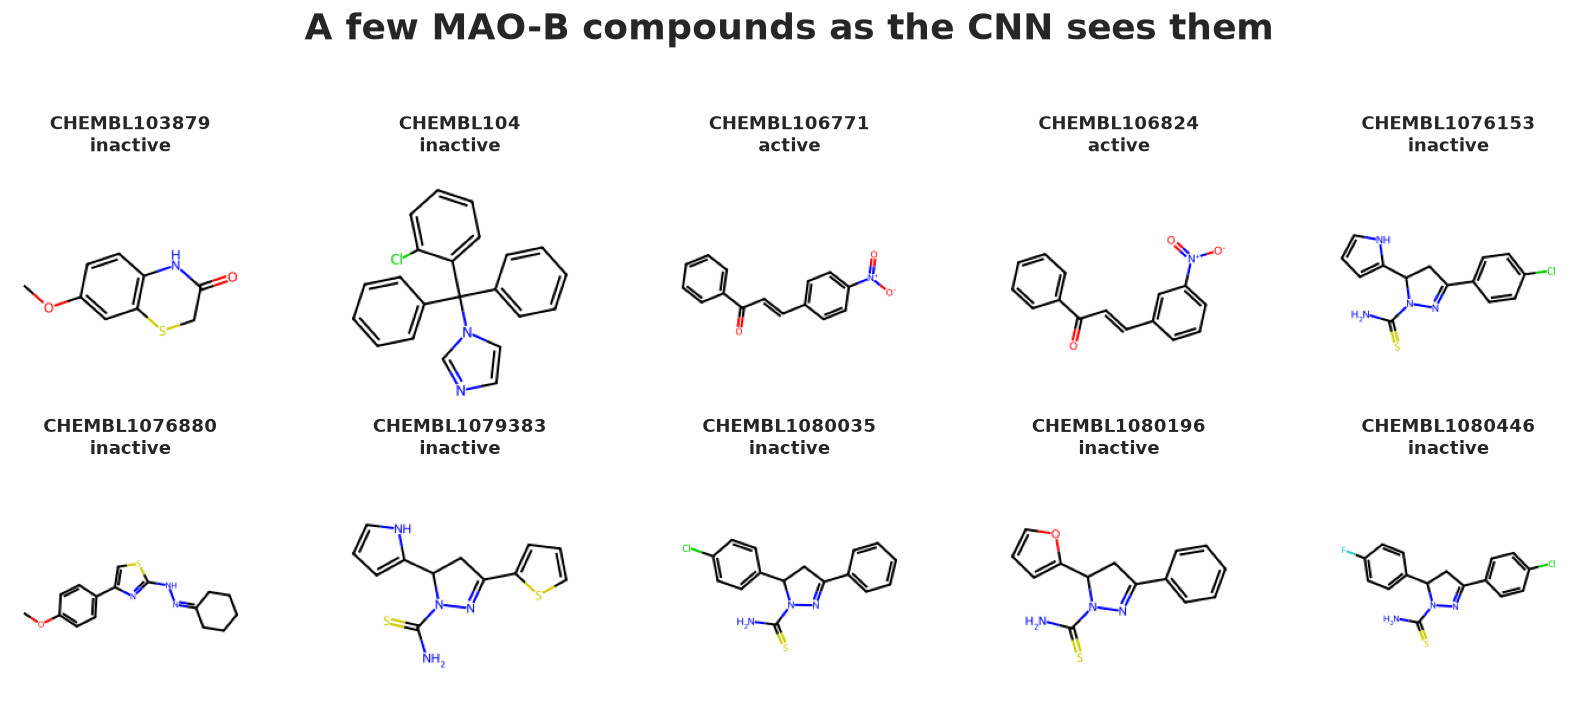

In [6]:
from rdkit.Chem import Draw

IMG_SIZE = 200


def structure_image(smiles):
    image = Draw.MolToImage(Chem.MolFromSmiles(smiles), size=(IMG_SIZE, IMG_SIZE))
    return np.asarray(image.convert("RGB"), dtype=np.uint8)


images = np.stack([structure_image(s) for s in data["smiles"]])
print(f"{images.shape[0]} images of {IMG_SIZE}x{IMG_SIZE} ({images.nbytes / 1e6:.0f} MB)")

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, i in zip(axes.flat, range(10)):
    ax.imshow(images[i])
    label = "active" if data["label"][i] else "inactive"
    ax.set_title(f"{data['molecule_chembl_id'][i]}\n{label}", fontsize=11)
    ax.axis("off")
fig.suptitle("A few MAO-B compounds as the CNN sees them", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

## Split the data before doing anything else

70% of the compounds train the model, 10% decide when to stop, and 20% are locked away until
the very end. Keeping that test set untouched is the single most important habit in ML for drug
discovery: every score you report should come from compounds the model has never seen. The split
is **stratified**, so each part keeps the same share of actives.

One honest caveat: a random split still lets close analogues of training compounds land in the
test set, which flatters the scores. Splitting by scaffold is the harder, more realistic test.

In [7]:
from sklearn.model_selection import train_test_split

y = data["label"].to_numpy()
idx_train, idx_test = train_test_split(np.arange(len(data)), test_size=0.2, stratify=y, random_state=42)
idx_train, idx_valid = train_test_split(idx_train, test_size=0.125, stratify=y[idx_train], random_state=42)

for name, idx in [("train", idx_train), ("validation", idx_valid), ("test", idx_test)]:
    print(f"{name:>10}: {len(idx):5d} compounds, {y[idx].mean():.0%} active")

     train:  2725 compounds, 39% active
validation:   390 compounds, 39% active
      test:   779 compounds, 40% active


In [8]:
X_train, X_valid, X_test = images[idx_train], images[idx_valid], images[idx_test]
y_train, y_valid, y_test = y[idx_train], y[idx_valid], y[idx_test]

For the imbalance, rather than copying images this notebook weights each class in the loss by the
inverse of its size, so the rarer actives count for more per example.

In [9]:
counts = np.bincount(y_train)
class_weight = {c: float(len(y_train) / (2 * n)) for c, n in enumerate(counts)}
print("Class weights:", {k: round(v, 2) for k, v in class_weight.items()})

Class weights: {0: 0.83, 1: 1.27}


## The model

Three convolution-and-pooling blocks learn visual features, then a small dense head outputs one
probability that the compound is active. Pixels are scaled to 0-1 inside the model.

In [10]:
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)

model = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Rescaling(1 / 255),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
], name="maob_2d_cnn")
model.compile(loss="binary_crossentropy", optimizer="adam",
              metrics=["accuracy", keras.metrics.AUC(name="auc")])
model.summary()

Model: "maob_2d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,333,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,426,945 (16.89 MB)

 Trainable params: 4,426,945 (16.89 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, min_delta=1e-4, restore_best_weights=True),
    keras.callbacks.CSVLogger("maob_cnn_images_training.csv"),
]
history = model.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=50,
                    batch_size=32, class_weight=class_weight, callbacks=callbacks)

Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 310ms/step - accuracy: 0.5908 - auc: 0.6348 - loss: 0.6618 - val_accuracy: 0.6718 - val_auc: 0.7365 - val_loss: 0.5842
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 287ms/step - accuracy: 0.6947 - auc: 0.7801 - loss: 0.5609 - val_accuracy: 0.6744 - val_auc: 0.7677 - val_loss: 0.6010
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 277ms/step - accuracy: 0.7659 - auc: 0.8560 - loss: 0.4703 - val_accuracy: 0.7282 - val_auc: 0.8036 - val_loss: 0.5384
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 284ms/step - accuracy: 0.8334 - auc: 0.9178 - loss: 0.3615 - val_accuracy: 0.7333 - val_auc: 0.8151 - val_loss: 0.5323
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 43s 306ms/step - accuracy: 0.8796 - auc: 0.9520 - loss: 0.2787 - val_accuracy: 0.7154 - val_auc: 0.8275 - val_loss: 0.6338
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 282ms/step - accuracy: 0.9042 - auc: 0.9718 - loss: 0.2099 - val_accuracy: 0.7256 - val_auc: 0.8407 - val_loss: 0.6575
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━

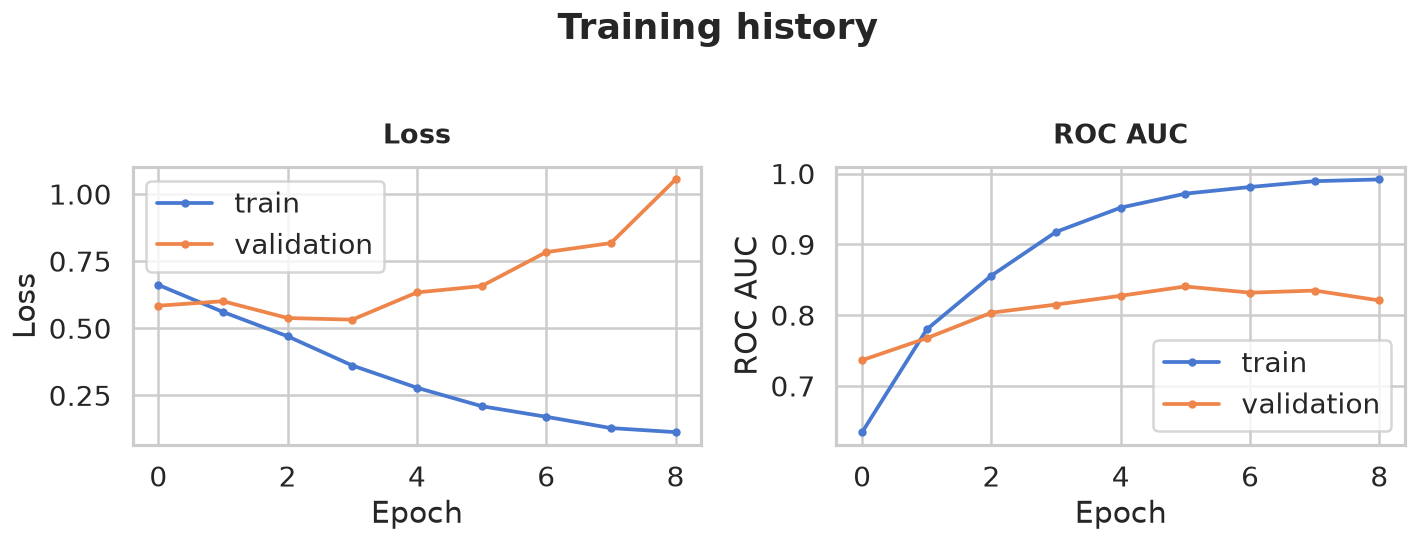

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, metric, title in zip(axes, ["loss", "auc"], ["Loss", "ROC AUC"]):
    ax.plot(history.history[metric], marker="o", ms=4, label="train")
    ax.plot(history.history[f"val_{metric}"], marker="o", ms=4, label="validation")
    ax.set(xlabel="Epoch", ylabel=title, title=title)
    ax.legend(frameon=True)
fig.suptitle("Training history", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

## How good is it, really?

Scores on the held-out compounds. The model outputs one probability, so "active" means at least
0.5. ROC AUC ignores that threshold; MCC and the report use it.

ROC AUC: 0.862
MCC:     0.543

              precision    recall  f1-score   support

    inactive       0.86      0.74      0.80       471
      active       0.67      0.81      0.74       308

    accuracy                           0.77       779
   macro avg       0.77      0.78      0.77       779
weighted avg       0.79      0.77      0.77       779



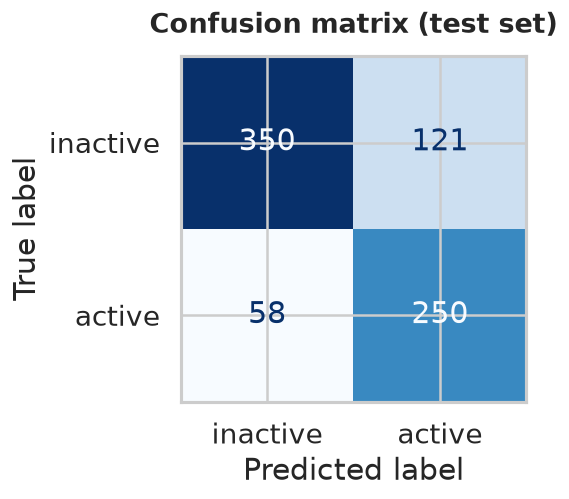

In [13]:
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             matthews_corrcoef, roc_auc_score)

p_test = model.predict(X_test, verbose=0).ravel()
pred_test = (p_test >= 0.5).astype(int)

print(f"ROC AUC: {roc_auc_score(y_test, p_test):.3f}")
print(f"MCC:     {matthews_corrcoef(y_test, pred_test):.3f}\n")
print(classification_report(y_test, pred_test, target_names=["inactive", "active"]))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, display_labels=["inactive", "active"],
                                        cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

## Reality check: a random forest on the same split

Before celebrating a neural network, see whether something simpler does just as well. A random
forest on the same fingerprints trains in seconds and needs no tuning. If the network cannot beat
it on the same held-out compounds, the extra complexity is not earning its keep.

In [14]:
from rdkit.Chem import rdFingerprintGenerator
from sklearn.ensemble import RandomForestClassifier

morgan = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fp = np.array([morgan.GetFingerprintAsNumPy(Chem.MolFromSmiles(s)) for s in data["smiles"]],
              dtype=np.uint8)

rf = RandomForestClassifier(n_estimators=500, class_weight="balanced", n_jobs=-1, random_state=42)
rf.fit(fp[idx_train], y_train)
p_rf = rf.predict_proba(fp[idx_test])[:, 1]
print(f"Random forest ROC AUC: {roc_auc_score(y_test, p_rf):.3f}")

Random forest ROC AUC: 0.977


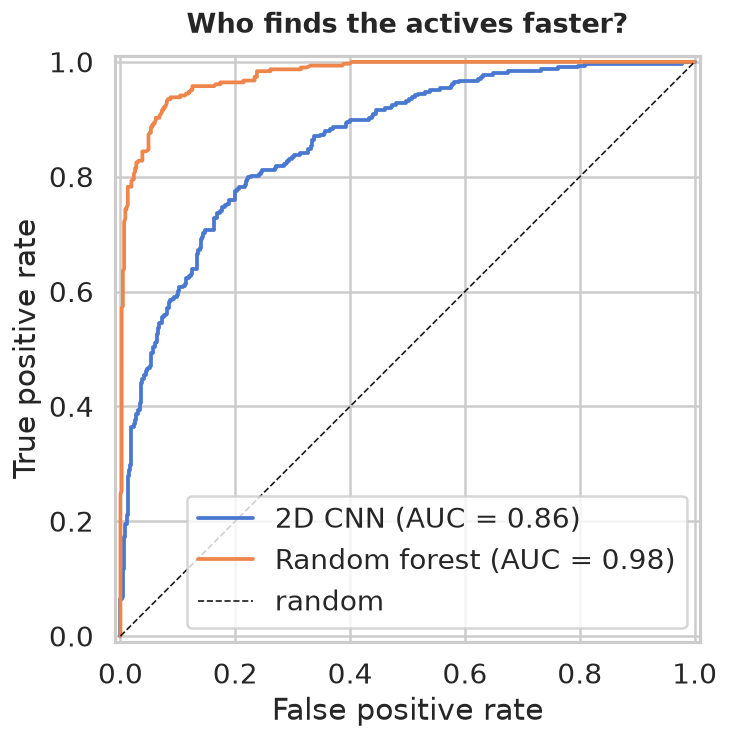

In [15]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6.5, 6.5))
RocCurveDisplay.from_predictions(y_test, p_test, name="2D CNN", ax=ax)
RocCurveDisplay.from_predictions(y_test, p_rf, name="Random forest", ax=ax)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="random")
ax.set(title="Who finds the actives faster?", xlabel="False positive rate", ylabel="True positive rate")
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

## Takeaways

- Reading structures as images is a genuinely different approach, but it throws away the exact
  connectivity a fingerprint keeps, and needs far more data to shine. Even with a few thousand
  compounds it falls well short of the fingerprint random forest, as the ROC comparison shows.
- The training history shows it memorising the training images within a few epochs while the
  validation loss climbs; early stopping keeps the weights from before that turn.
- The habits carry over from the previous notebook: clean split, no leakage, always a baseline.
- Next: augment the images (rotations, flips) since a molecule's identity does not depend on how
  it is drawn, or tune with [KerasTuner](https://keras.io/keras_tuner/) on the validation set only.

The trained model is saved below.

In [16]:
model.save("maob_cnn_images.keras")

try:  # on Colab, offer the saved model as a download
    from google.colab import files
    files.download("maob_cnn_images.keras")
except ImportError:
    pass